In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction
import numpy as np
np.random.seed(5)
from utils.sampling import sample
from sklearn.preprocessing import StandardScaler
import pandas as pd
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs
import seaborn as sns

2024-03-20 11:16:07.294599: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-20 11:16:07.294646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-20 11:16:07.295583: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-20 11:16:07.302664: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-20 11:16:08.089441: W tensorflow/compiler/tf2

In [142]:
df, columns, target = load_breast_cancer_data()

In [143]:
df[columns] = StandardScaler().fit_transform(df[columns])

In [144]:
N, R = sample(
            "less_negative_class",
            df,
            target,
            train_fraction=0.5,
            bias_fraction=0.1,
            columns=columns,
        )

In [145]:
drop_index, feature_importance = mrs(N, R, columns, class_weights="balanced")

In [146]:
def temperature_softmax(temperature, weights):
    individual_exp = np.exp(weights / temperature)
    sum_exp = np.sum(individual_exp)
    return individual_exp / sum_exp

In [147]:
def compute_feature_weights(budget, feature_importance):
    max_importance = np.max(np.abs(feature_importance))
    normalized_feature_importance = temperature_softmax(budget, -feature_importance)
    #print(normalized_feature_importance)
    return normalized_feature_importance

<Axes: >

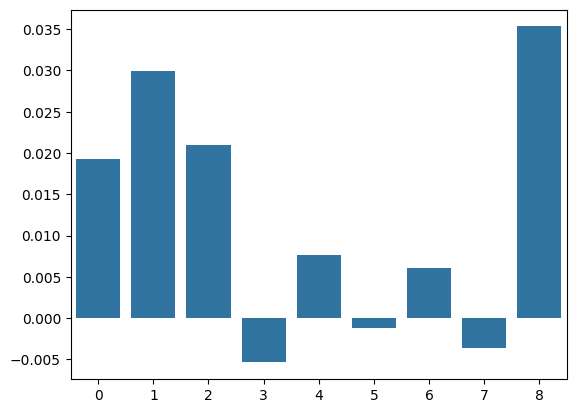

In [148]:
sns.barplot( feature_importance )

<Axes: >

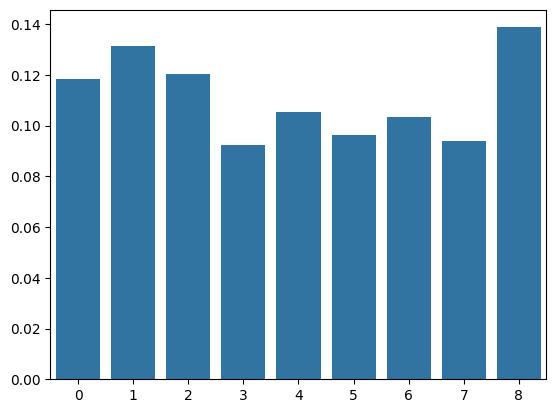

In [173]:
feature_weights = compute_feature_weights(0.1, -feature_importance)
sns.barplot(feature_weights)

In [176]:
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_classifier_forest, train_feature_weighted_classifier_tree
seed = 5
budget = 1
max_features = "sqrt"
max_depth = None
auroc_method = train_feature_weighted_classifier_forest
weights = temperature_softmax(budget, -feature_importance)
auroc = compute_test_metrics_fw_mrs(
    pd.concat([N, R]),
    columns,
    random_state=seed,
    feature_weights=weights,
    method=auroc_method,
    draw_with_feature_weights=True,
    class_weight=None,
    speedup=True,
    max_features=max_features,
    splitter="feature_weighted_random",
    n_splits_test=25,
    max_depth=max_depth,
)
print(auroc)

0.6548937728937729
